In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

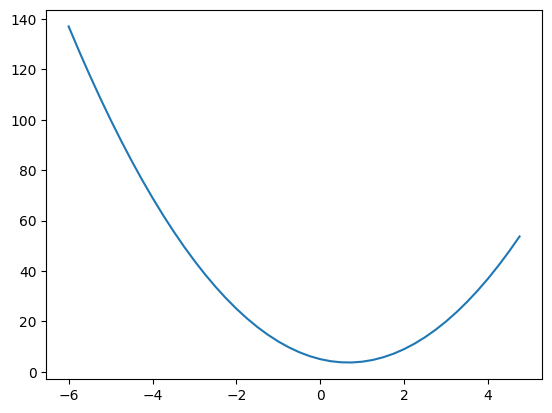

In [10]:
xs = np.arange(-6, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [14]:
# Derivative example
h = 0.001
x= -3
(f(x + h)- f(x))/ h

-21.996999999998934

In [46]:
a = 2
b = -3
c = 10
d = a*b + c
d
# More complex derivative example
h = 0.0001
d1 = d
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4
d2 3.999699999999999
slope -3.000000000010772


# NN structure

In [135]:
class Value:

    def __init__(self, data, _children = (), _op = ' ', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None # by default, does nothing
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad # multiplying by out.grad is chain rule
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other): # raise value to some power
        assert isinstance(other, (int, float)) # only supports int or float exp
        out = Value(self.data ** other, (self, ), f'**(other)')

        def _backward():
            self.grad += other * self.data ** (other - 1) * out.grad
        out._backward = _backward

        return out

    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other):
        return self * other ** -1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1- t**2) * out.grad
        out._backward = _backward
    
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
            for child in v._prev:
                build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [72]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10)
## calls a.__add__(b)
d = a * b + c
d
## (a.__mul__(b)).__add__(c)

Value(data=4.0)

In [45]:
d._prev

{Value(data=-6.0), Value(data=10)}

In [46]:
d._op

'+'

In [63]:
a = Value(2)
# a + 1 is not valid bc 1 is not a Value object, only valid after adding the if statement in __add__ that converts to Value
a + 1
2 * a # valid from __rmul__, which is the fall back since 2.__mul__(a) is not valid as 2 is not a Value obj

Value(data=4)

In [73]:
a - b
a / b

Value(data=-0.6666666666666666)

In [11]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

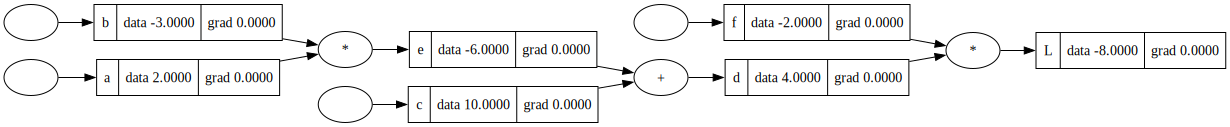

In [41]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
draw_dot(L)

### In forward prop, calculate subsequent and eventually final values

### In back prop, calculate gradient of final value wrt to each previous node (weights). Do this via chain rule
### for each subsequent backwards layer

# Neuron

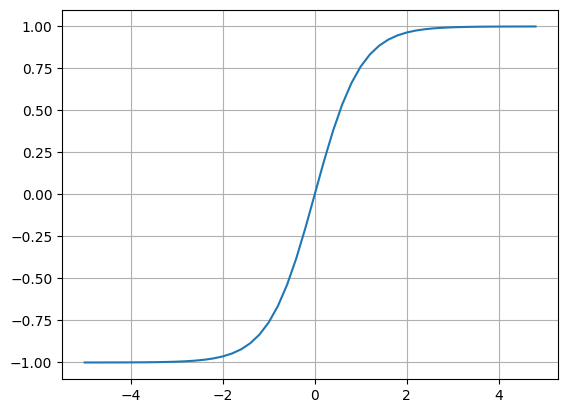

In [5]:
# Activation fcn
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

Cell body = $w_1x_1 + w_2x_2 + b$, where $x_i$ are input neurons

We mostly care about derivative wrt $w_i$, as these weights are whats modified

In [42]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

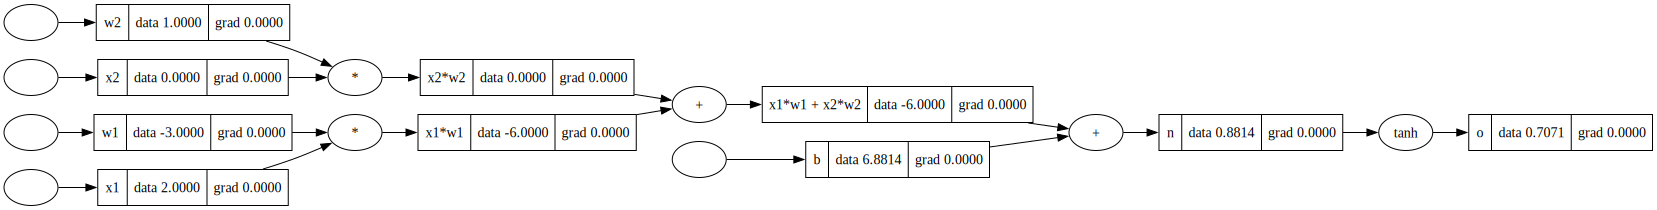

In [ ]:
draw_dot(o)

In [18]:
o.grad = 1.0 # was originally initialized to 0.0
o._backward() # finds the gradient of the previous neuron, aka do/dn
# rerun draw_dot(o) to fill in gradient for n cell

In [20]:
n._backward()

In [24]:
b._backward() # nothing happens since b has no inputs
x1w1x2w2._backward()

In [26]:
x1w1._backward()
x2w2._backward()

We can use topological sort to order the MLP and subsequently calculate gradients (to be embedded as a method)

In [33]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
    for child in v._prev:
        build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [36]:
o.grad = 1

for node in reversed(topo):
    node._backward()
# this instantly fill out the entire MLP backprop

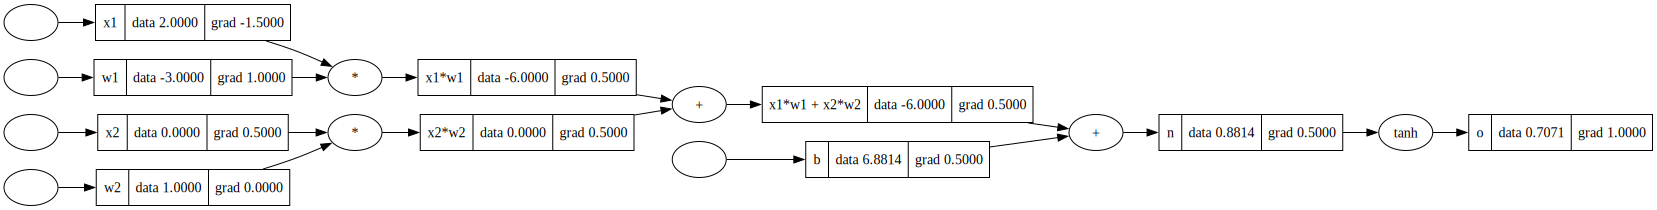

In [35]:
draw_dot(o)

In [ ]:
o.backward() # uses embedded method

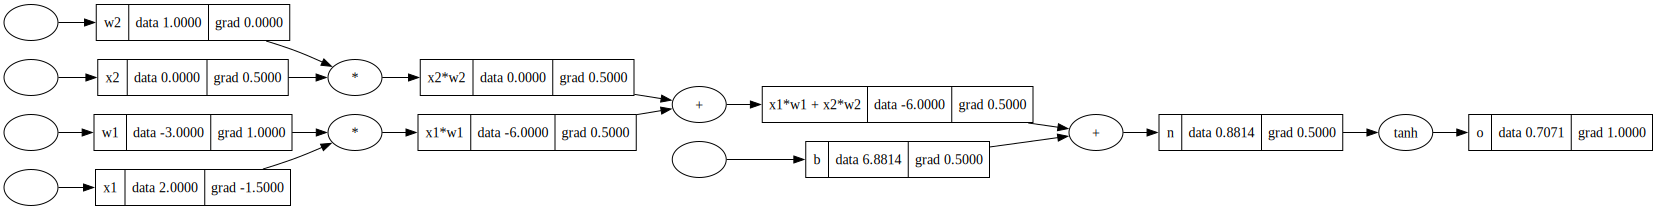

In [45]:
draw_dot(o)

## Torch implementation

In [ ]:
import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True # by default, torch assumes no gradient needed
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item()) # forward pass value of o
o.backward()

print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

x2.grad # this is a tensor, adding .item() picks out the value

0.7071066904050358
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


tensor([0.5000], dtype=torch.float64)

## Implementation of a single neuron (similar to Torch)

In [136]:
import random

class Neuron:
    
    def __init__(self, nin): # nin = number of inputs
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)] # initialization of list of random weights
        self.b = Value(random.uniform(-1, 1)) #initialization of random bias

    def __call__(self, x): # lets obj behave like function so we can do n(x)
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
        # zip takes 2+ lists, aligns them into list of tuples, so this first aligns w_i with x_i
        # sum looks like sum(iterable, start_value)

    def parameters(self):
        return self.w + [self.b]

x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=0.5840588592980374)

In [137]:
class Layer:

    def __init__(self, nin, nout): # nout = number of neurons per layer
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
x = [2.0, 3.0]
n = Layer(2, 3) # 2 inputs per neuron (matches dim of x), 3 neurons per layer
n(x)

[Value(data=0.6327401474729675),
 Value(data=0.6320838882824079),
 Value(data=0.7636426296970047)]

In [138]:
class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts # size
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

x = [2, 3, -1]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.3258058160522169)

In [139]:
len(n.parameters()) # number of total weights and biases in MLP

41

In [140]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.3258058160522169),
 Value(data=-0.14431603267673554),
 Value(data=-0.30641470002431065),
 Value(data=-0.8465649582902338)]

In [144]:
# want to measure how well NN is performing, via loss
loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0))
loss

Value(data=7.986143095997666)

## Gradient descent

In [142]:
for k in range(20): # 20 step sizes
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0 # must zero grad before backward to prevent gradient accumulation
    loss.backward()

    # update
    for p in n.parameters():
        p.data += 0.01 * p.grad # change weight slightly, loss should be slightly lower each step

    print(k, loss.data)

0 6.380818827339745
1 7.892228496528597
2 7.906260063973414
3 7.932125155993977
4 7.944780698364687
5 7.957856635753932
6 7.961299930674304
7 7.96623627820452
8 7.9685599169034385
9 7.973525569854887
10 7.9744969806387145
11 7.976689407249704
12 7.977816973975541
13 7.9809033525798965
14 7.98176136405211
15 7.98376430033317
16 7.9841341655570695
17 7.985158203177285
18 7.985712826729898
19 7.986143095997666
